In [1]:
from gammaraytoys.detectors import ToyCodedMaskDetector3D
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.coordinates import Angle, SkyCoord, UnitSphericalRepresentation
from astropy.units import Quantity
from scipy.stats import poisson, norm, chi2
from histpy import Histogram, Axis

from gammaraytoys import poisson_binned_log_likelihood, unbinned_log_likelihood, richardson_lucy

import cProfile

%load_ext line_profiler

In [2]:
det = ToyCodedMaskDetector3D.create_random_mask(mask_size = 40 * u.cm, 
                                                mask_npix = 130, 
                                                mask_separation = 100 * u.cm, 
                                                open_fraction = .5, 
                                                detector_size = 22 * u.cm, 
                                                detector_npix = 440, 
                                                detector_efficiency = 0.65)

(<Axes: xlabel='x [cm]', ylabel='y [cm]'>,
 <matplotlib.collections.QuadMesh at 0x12b06d950>)

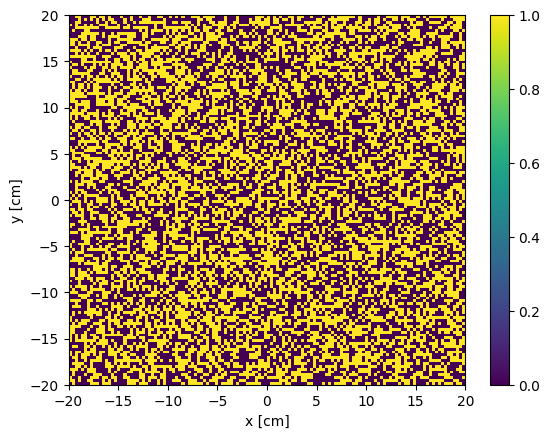

In [3]:
det.mask.plot()

(<Axes: xlabel='x [cm]', ylabel='y [cm]'>,
 <matplotlib.collections.QuadMesh at 0x12b19f010>)

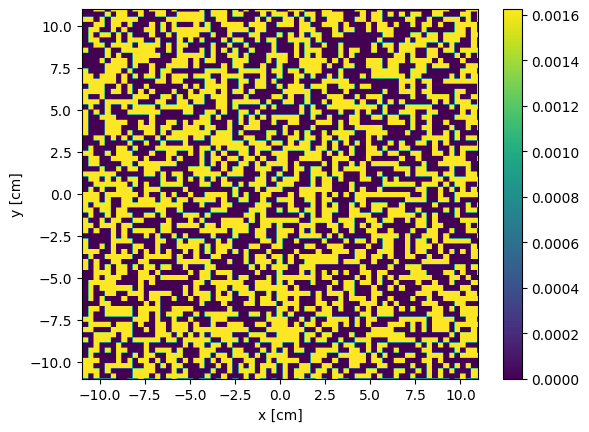

In [4]:
coord = SkyCoord(l = 0.1*u.deg, b = 1*u.deg, frame = 'galactic')

flux = 1/u.cm/u.cm/u.s
duration = 1*u.s

shadowgram = det.point_source_response(flux, duration, coord)

shadowgram.plot()

In [5]:
coord = SkyCoord(l = 0.1*u.deg, b = 14*u.deg, frame = 'galactic')
det.effective_area(coord)

<Quantity 41.55381571 cm2>

In [6]:
# Works, but it's slow
#det.response

In [7]:
def f():
    
    flux = 1/u.cm/u.cm/u.s
    coord = UnitSphericalRepresentation(lon = 0*u.deg, lat = 0*u.deg)
    width_lon = 0*u.arcmin
    width_lat = 0*u.arcmin
    
    width_lon = np.maximum(det.angular_resolution/1e6, width_lon)
    width_lat = np.maximum(det.angular_resolution/1e6, width_lat)
    
    model = Histogram(det.sky_axes, unit = flux.unit) 
    
    from scipy.stats import multivariate_normal
    from scipy.integrate import dblquad
    
    dist = multivariate_normal(mean = [coord.lon.to_value(u.rad), coord.lon.to_value(u.rad)],
                               cov = [[width_lon.to_value(u.rad)**2,0],[0,width_lat.to_value(u.rad)**2]])

    # Mask at 3 sigma for speed
    max_sigma = 3
    nLon_list = np.arange(det.sky_axes['lon'].nbins)
    lon_lower_bounds = det.sky_axes['lon'].lower_bounds 
    lon_centers = det.sky_axes['lon'].centers
    lon_upper_bounds = det.sky_axes['lon'].upper_bounds

    lon_mask = (lon_lower_bounds - coord.lon < max_sigma*width_lon) & (coord.lon - lon_upper_bounds < max_sigma*width_lon)
    nLon_list = nLon_list[lon_mask]
    lon_lower_bounds = lon_lower_bounds[lon_mask]
    lon_centers = lon_centers[lon_mask]
    lon_upper_bounds = lon_upper_bounds[lon_mask]

    nLat_list = np.arange(det.sky_axes['lat'].nbins)
    lat_lower_bounds = det.sky_axes['lat'].lower_bounds 
    lat_centers = det.sky_axes['lat'].centers 
    lat_upper_bounds = det.sky_axes['lat'].upper_bounds

    lat_mask = (lat_lower_bounds - coord.lat < max_sigma*width_lat) & (coord.lat - lat_upper_bounds < max_sigma*width_lat)
    nLat_list = nLat_list[lat_mask]
    lat_lower_bounds = lat_lower_bounds[lat_mask]
    lat_centers = lat_centers[lat_mask]
    lat_upper_bounds = lat_upper_bounds[lat_mask]

    for nLon,lon_i, lon_c, lon_f in zip(nLon_list, lon_lower_bounds, lon_centers, lon_upper_bounds):
        for nLat,lat_i, lat_c, lat_f in zip(nLat_list, lat_lower_bounds, lat_centers, lat_upper_bounds):

            # The main purpose of this line is to make dblquadis work if the width is tiny
            upper_lon = np.minimum(lon_f, coord.lon + max_sigma*width_lon).to_value(u.rad)
            lower_lon = np.maximum(lon_i, coord.lon - max_sigma*width_lon).to_value(u.rad)
            upper_lat = np.minimum(lat_f, coord.lat + max_sigma*width_lat).to_value(u.rad)
            lower_lat = np.maximum(lat_i, coord.lat - max_sigma*width_lat).to_value(u.rad)
            
            pdf_int,_ = dblquad(lambda y,x: dist.pdf([x,y]), 
                                 lower_lon, upper_lon, 
                                 lower_lat, upper_lat)

            # pdf_int = dist.pdf([lon_c,lat_c]) * (lon_f - lon_i).to_value(u.rad) * (lat_f - lat_i).to_value(u.rad) * np.cos(lat_c)
    
            model[nLon, nLat] = flux*pdf_int
    
    model *= flux/np.sum(model)

    return model

In [8]:
%lprun -f f model = f()

Timer unit: 1e-09 s

Total time: 0.170603 s
File: /var/folders/3_/k9d8ljjn5hv2xks5822zlyrm26_jpd/T/ipykernel_81385/1322242497.py
Function: f at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def f():
     2                                               
     3         1     377000.0 377000.0      0.2      flux = 1/u.cm/u.cm/u.s
     4         1     627000.0 627000.0      0.4      coord = UnitSphericalRepresentation(lon = 0*u.deg, lat = 0*u.deg)
     5         1      35000.0  35000.0      0.0      width_lon = 0*u.arcmin
     6         1      20000.0  20000.0      0.0      width_lat = 0*u.arcmin
     7                                               
     8         1     513000.0 513000.0      0.3      width_lon = np.maximum(det.angular_resolution/1e6, width_lon)
     9         1     259000.0 259000.0      0.2      width_lat = np.maximum(det.angular_resolution/1e6, width_lat)
    10                                    

In [6]:
flux = 1/u.cm/u.cm/u.s
coord = UnitSphericalRepresentation(lon = 0*u.deg, lat = 0*u.deg)
width_lon = 0*u.arcmin
width_lat = 0*u.arcmin

model = det.gaussian_model(flux, coord, width_lon, width_lat)

In [7]:
np.sum(model)

<Quantity 1. 1 / (s cm2)>

In [8]:
np.sum(model > 0)

np.int64(841)

(-1.0, 1.0)

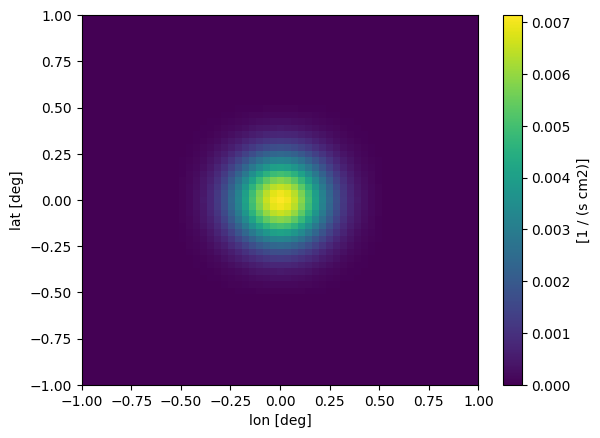

In [9]:
ax, _  = model.plot()

ax.set_xlim(-1,1)
ax.set_ylim(-1,1)

In [ ]:
model.plot()

In [ ]:
lon_unit,lat_unit

In [ ]:
det.response.contents.value.size*8*1e4/1e9

In [ ]:
import sys

sys.getsizeof(det.response.contents.value)

In [ ]:
50*1e4/3600

In [ ]:
det.response.project(0,1).plot()

In [ ]:
det.response.slice[0,1].project(2,3).plot()

In [ ]:
(np.prod(det.sky_axes.nbins) * np.prod(det.detector_axes.nbins)) * 8 / 1e9

In [ ]:
np.sum(shadowgram)

In [ ]:
cProfile.run('det.point_source_response(1/u.cm/u.cm/u.s, 1*u.s, coord)', filename = "psr.prof")

In [ ]:
%lprun -f det.point_source_response.__wrapped__ det.point_source_response(1/u.cm/u.cm/u.s, 1*u.s, coord)

In [ ]:
fig,ax = plt.subplots(subplot_kw={'projection':'3d'})

ax.plot_surface

In [ ]:
[[]]*10

In [ ]:
a = np.full(10, tuple([]), dtype = object)

In [ ]:
for mask_i, geom_weight in [[1, .5]]:
    print(mask_i, geom_weight)

In [ ]:
a[0] = tuple([[1, .5]])

In [ ]:
a

In [ ]:
x = [3,4,5]
x += [5,6]

In [ ]:
x